In [1]:
1+1

2

### Building chatbot with multiple tool using Langgraph

### Aim 
Create a chatbot with tool capabilities from arxiv , wikipedia search and some functions

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [5]:
from langchain.tools import tool
import arxiv

@tool
def search_arxiv(query: str) -> str:
    """Search papers from Arxiv."""

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=2,
        sort_by=arxiv.SortCriterion.Relevance
    )

    results = []

    for paper in client.results(search):
        results.append(
            f"Title: {paper.title}\n"
            f"Summary: {paper.summary[:500]}"
        )

    return "\n\n".join(results)

print(search_arxiv.invoke("Attention is all you need"))

Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a

Title: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
Summary: The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponential g

In [7]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wiki.name)

wikipedia


In [8]:
wiki.invoke("What is Machine Learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from pre-trained data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical opt'

In [9]:
from dotenv import load_dotenv
import os 
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()


C:\Users\tejas\AppData\Local\Temp\ipykernel_4196\988821005.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [11]:
tavily.invoke("Provide me recent AI news for June 7 2026")

[{'title': 'AI News Briefs BULLETIN BOARD for June\xa02026 | Radical Data Science',
  'url': 'https://radicaldatascience.wordpress.com/2026/06/04/ai-news-briefs-bulletin-board-for-june-2026',
  'content': '[6/1/2026] The AI Layoff Trap – Two economists just published a mathematical proof that AI will destroy the economy. Not might. Not could. Will — if nothing changes. The paper is called “The AI Layoff Trap.” Published March 2, 2026. Wharton School, University of Pennsylvania. Boston University. Peer reviewed. Mathematically modeled. The conclusion is one sentence.  \n“At the limit, firms automate their way to boundless productivity and zero demand.” [...] The filing lands in the hottest AI IPO window in history. SpaceX — which merged with Elon Musk’s xAI earlier this year — is targeting a $2 trillion valuation in its own pending offering and seeking to raise more than $75 billion. OpenAI, which raised $122 billion in March at an $852 billion valuation, is expected to file its own S-1

In [12]:
### Combine all the tools in the list
tools = [search_arxiv,wiki,tavily]

In [13]:
## Intialize LLM model
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm_with_tools = llm.bind_tools(tools)

In [15]:
from pprint import pprint
from langchain_core.messages import HumanMessage , AIMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 't5qrz5j4j',
  'type': 'tool_call'}]

In [16]:
## State Schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

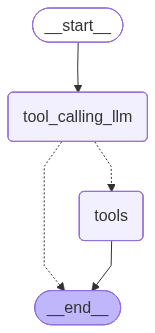

In [18]:
### Entire Chatbot with Langgraph
from langgraph.graph import StateGraph,START,END 
from IPython.display import display,Image
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", END)

graph_builder = builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [20]:
messages = graph_builder.invoke(
    {
        "messages": HumanMessage(
            content="What is attention is all you need"
        )
    }
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is attention is all you need
================================== Ai Message ==================================
Tool Calls:
  wikipedia (97x6y0e21)
 Call ID: 97x6y0e21
  Args:
    query: attention is all you need
================================= Tool Message =================================
Name: wikipedia

Page: Attention Is All You Need
Summary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the 


In [21]:
messages = graph_builder.invoke(
    {
        "messages": HumanMessage(
            content="Provide top 2 AI news in world trending"
        )
    }
)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide top 2 AI news in world trending
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (3x4gvcbw8)
 Call ID: 3x4gvcbw8
  Args:
    query: top 2 AI news in world trending
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Artificial Intelligence - Latest AI News and Analysis - WSJ.com", "url": "https://www.wsj.com/tech/ai", "content": "Image 2: Estonia Is Fighting Brain Rot—With Free ChatGPT\n\n1.   The Future of Everything \n\n### Estonia Is Fighting Brain Rot—With Free ChatGPT\n\nPlus, the push to bypass Chinese rare earths and the scramble to ban personalized pricing.\n\nBy\n\nConor Grant\n\nJune 5, 2026\n\nImage 3: U.S. Officials Discuss Taking Financial Stakes in AI Industry\n\n1.   Tech \n\n### U.S. Officials Discuss Taking Financial Stakes in AI Indus